In [1]:
import numpy as np 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, Dropout 
from tensorflow.keras.optimizers import RMSprop 
from tensorflow.keras.datasets import mnist 
import matplotlib.pyplot as plt 
from sklearn import metrics 

In [2]:
# The MNIST dataset is a built-in dataset provided by Keras. 
# It consists of 70,000 28x28 grayscale images, each of which displays a single handwritten digit from 0 to 9. 
# The training set consists of 60,000 images, while the test set has 10,000 images. 
(x_train, y_train), (x_test, y_test) = mnist.load_data() 

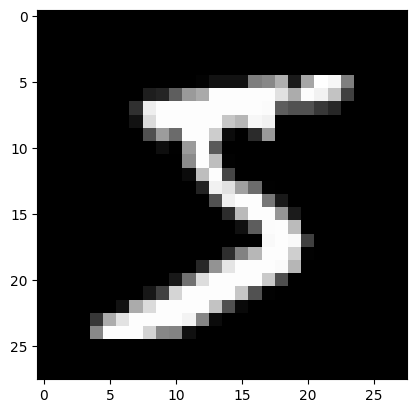

In [3]:
plt.imshow(x_train[0], cmap='gray') # imshow() function which simply displays an image. 
plt.show()

In [4]:
print(x_train[0]) 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [5]:
print("X_train shape", x_train.shape) 
print("y_train shape", y_train.shape) 
print("X_test shape", x_test.shape) 
print("y_test shape", y_test.shape) 

X_train shape (60000, 28, 28)
y_train shape (60000,)
X_test shape (10000, 28, 28)
y_test shape (10000,)


In [6]:
x_train = x_train.reshape(60000, 784) 
x_test = x_test.reshape(10000, 784) 
x_train = x_train.astype('float32')

In [7]:
x_test = x_test.astype('float32') 
x_train /= 255 # Each image has Intensity from 0 to 255 
x_test /= 255

In [8]:
num_classes = 10 
y_train = np.eye(num_classes)[y_train] 

In [9]:
y_test = np.eye(num_classes)[y_test] 

In [10]:
model = Sequential() 
model.add(Dense(512, activation='relu', input_shape=(784,))) 

C:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.add(Dropout(0.2)) # DROP OUT RATIO 20% 
model.add(Dense(512, activation='relu')) #returns a sequence of another vectors of dimension 512 
model.add(Dropout(0.2)) 
model.add(Dense(num_classes, activation='softmax'))

In [12]:
model.compile(loss='categorical_crossentropy', # for a multi-class classification problem 
optimizer=RMSprop(), 
metrics=['accuracy']) 

In [13]:
batch_size = 128 # batch_size argument is passed to the layer to define a batch size for the inputs. 
epochs = 20 
history = model.fit(x_train, y_train, 
    batch_size=batch_size, 
    epochs=epochs, 
    verbose=1, # verbose=1 will show you an animated progress bar eg. [==========] 
    validation_data=(x_test, y_test))

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.9211 - loss: 0.2569 - val_accuracy: 0.9624 - val_loss: 0.1226
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9676 - loss: 0.1048 - val_accuracy: 0.9762 - val_loss: 0.0759
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9773 - loss: 0.0734 - val_accuracy: 0.9794 - val_loss: 0.0660
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9818 - loss: 0.0577 - val_accuracy: 0.9799 - val_loss: 0.0676
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9850 - loss: 0.0469 - val_accuracy: 0.9838 - val_loss: 0.0575
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.9870 - loss: 0.0408 - val_accuracy: 0.9824 - val_loss: 0.0654
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9890 - loss: 0.0340 - val_accuracy: 0.9818 - val_loss: 0.0660
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9908 - loss: 0.0292 - val_

In [14]:
score = model.evaluate(x_test, y_test) 
print('Test loss:', score[0]) 
print('Test accuracy:', score[1]) 

Test loss: 0.07922611385583878
Test accuracy: 0.986299991607666
